# TDL encoder ablation: sheaf, cell-complex, simplicial-1, and GNN

This notebook compares four encode/decode stacks against the **same** linear
graph Koopman head (`koopman="graph"`) on one seeded Laplacian-diffusion
fixture with a small filled / triangulated complex. Widths, training budget,
and latent operator class are held fixed so that any gap is attributable to
the encoder family.

**Objective.** Report multi-seed multi-step mean squared error (MSE) with
run-to-run variability. On this tiny teaching fixture the arms are often
indistinguishable within noise — treat a null result as expected, not as a
failure of topological deep learning (TDL). The in-repo cell-complex peer
reuses the simplicial-1 node mixer, so bit-identical `simplicial` /
`cell_complex` scores are also expected.

**Prerequisites.** An installed `koopman_graph` environment. Continuous-
integration notebook smoke (`nbmake`) sets a short `IS_TEST` path. Stored
outputs below are the intentional teaching run (`IS_TEST=False`, three
seeds) so the bar chart is readable without re-execution; CI still uses the
short path.

> **Honesty.** This is a teaching ablation on a synthetic complex, not a
> replacement for dedicated TDL frameworks on complex-native tasks, and not
> a claim that sheaf or cell-complex encoders outperform graph convolutional
> networks (GCNs) in general.


## Setup


In [1]:
import os
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import (
    CellComplexGNNDecoder,
    CellComplexGNNEncoder,
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    SheafGNNDecoder,
    SheafGNNEncoder,
    SimplicialDecoder,
    SimplicialEncoder,
)
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets.dynamics import (
    diffusion_sequence_from_features,
    laplacian_diffusion_rollout,
    make_generator,
)
from koopman_graph.nn.cell_complex import CellComplex, boundary_operator

IS_TEST = bool(
    os.environ.get("NBMAKE")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)

FEATURES = 2
LATENT = 2
HIDDEN = 8 if IS_TEST else 16
NUM_LAYERS = 2
N = 3 if IS_TEST else 4
NUM_TIMESTEPS = 12 if IS_TEST else 40
HOLD_TIMESTEPS = 8 if IS_TEST else 16
STEPS = 2 if IS_TEST else 6
EPOCHS = 2 if IS_TEST else 40
LR = 5e-3
SEEDS = (0,) if IS_TEST else (0, 1, 2)
DIFFUSION = dict(
    diffusion_rate=0.35,
    decay_rate=0.92,
    noise_std=0.0,
    initial_state="ones",
)

torch.manual_seed(0)
print(
    f"koopman_graph {koopman_graph.__version__}; IS_TEST={IS_TEST}; "
    f"N={N}; seeds={SEEDS}; epochs={EPOCHS}; steps={STEPS}"
)


koopman_graph 0.11.0; IS_TEST=False; N=4; seeds=(0, 1, 2); epochs=40; steps=6


## Motivation and background

Version 0.10 shipped combinatorial simplicial-1 / Hodge lifts on oriented
`edge_index`. Version 0.11 adds diagonal (and optional general) sheaf
restriction maps and cell-complex boundary / Hodge helpers with factory peers
`encoder="sheaf"` and `encoder="cell_complex"`. The sheaf peers are teaching
MVPs in the spirit of sheaf neural networks and neural sheaf diffusion
([Hansen & Gebhart, 2020](https://arxiv.org/abs/2012.06333);
[Bodnar et al., 2022](https://doi.org/10.52202/068431-1346));
the cell-complex peers are a lightweight cellular precursor relative to CW /
cellular message-passing stacks
([Bodnar et al., 2021](https://arxiv.org/abs/2106.12575)). Because the latent
Koopman operator stays linear, an encoder ablation on a shared
`koopman="graph"` head is the cheapest check that the new stacks train and
that any accuracy gap is not an artifact of a different $K$.

On a three- or four-node complex the expressive differences among GCN-style
mixing, combinatorial $L_1$, sheaf $L_F$, and Hodge $L_0$ are modest. In
this package the combinatorial node operator is the same matvec as the
Hodge Laplacian on 0-cells:

$$
L_1 = B_1 B_1^{\top} \equiv L_0
\quad\text{(node features; package naming)}
$$

The cell-complex encoder reuses that matvec: faces are required for
cell-complex identity but do not change node mixing. Multi-seed reporting is
therefore required, and bit-identical `simplicial` / `cell_complex` rollouts
should be read as an MVP honesty check rather than as independent evidence
for two TDL families.


## Minimal example — matched peers and one-seed smoke

Build four encode/decode pairs at identical widths, confirm that matched-init
`SimplicialEncoder` and `CellComplexGNNEncoder` agree on a single snapshot
(faces do not enter the mix), then fit one `gnn` arm for a single seed as a
quick payoff before the full ablation.


In [2]:
def teaching_complex(num_nodes: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Oriented 1-skeleton and triangular 2-cells for the ablation fixture."""
    if num_nodes == 3:
        edge_index = torch.tensor([[0, 1, 0], [1, 2, 2]], dtype=torch.long)
        face_index = torch.tensor([[0], [1], [2]], dtype=torch.long)
        return edge_index, face_index
    if num_nodes == 4:
        edge_index = torch.tensor(
            [[0, 1, 0, 1, 2], [1, 2, 2, 3, 3]],
            dtype=torch.long,
        )
        face_index = torch.tensor([[0, 1], [1, 2], [2, 3]], dtype=torch.long)
        return edge_index, face_index
    raise ValueError(f"teaching_complex supports N in {{3, 4}}, got {num_nodes}")


ARM_BUILDERS = {
    "gnn": lambda: (
        GNNEncoder(FEATURES, HIDDEN, LATENT, num_layers=NUM_LAYERS),
        GNNDecoder(LATENT, HIDDEN, FEATURES, num_layers=NUM_LAYERS),
    ),
    "simplicial": lambda: (
        SimplicialEncoder(FEATURES, HIDDEN, LATENT, num_layers=NUM_LAYERS),
        SimplicialDecoder(LATENT, HIDDEN, FEATURES, num_layers=NUM_LAYERS),
    ),
    "sheaf": lambda: (
        SheafGNNEncoder(FEATURES, HIDDEN, LATENT, num_layers=NUM_LAYERS),
        SheafGNNDecoder(LATENT, HIDDEN, FEATURES, num_layers=NUM_LAYERS),
    ),
    "cell_complex": lambda: (
        CellComplexGNNEncoder(FEATURES, HIDDEN, LATENT, num_layers=NUM_LAYERS),
        CellComplexGNNDecoder(LATENT, HIDDEN, FEATURES, num_layers=NUM_LAYERS),
    ),
}

edge0, face0 = teaching_complex(N)
x0 = torch.ones(N, FEATURES)
snap0 = Data(x=x0, edge_index=edge0, face_index=face0)
torch.manual_seed(0)
simp_enc, _ = ARM_BUILDERS["simplicial"]()
torch.manual_seed(0)
cell_enc, _ = ARM_BUILDERS["cell_complex"]()
torch.manual_seed(0)
sheaf_enc, _ = ARM_BUILDERS["sheaf"]()
with torch.no_grad():
    z_simp = simp_enc(snap0)
    z_cell = cell_enc(snap0)
    z_sheaf = sheaf_enc(snap0)
init_cell_gap = float((z_simp - z_cell).abs().max().item())
init_sheaf_gap = float((z_simp - z_sheaf).abs().max().item())
print(
    f"matched-init max|simplicial-cell|={init_cell_gap:.3e}; "
    f"max|simplicial-sheaf|={init_sheaf_gap:.3e}"
)
assert init_cell_gap == 0.0

smoke_train = GraphSnapshotSequence(
    [
        Data(
            x=torch.ones(N, FEATURES) * (0.9**t),
            edge_index=edge0.clone(),
            face_index=face0.clone(),
        )
        for t in range(max(4, STEPS + 2))
    ]
)
torch.manual_seed(0)
enc, dec = ARM_BUILDERS["gnn"]()
smoke = GraphKoopmanModel(
    encoder=enc,
    decoder=dec,
    latent_dim=LATENT,
    time_step=1.0,
    koopman="graph",
)
_ = smoke.fit(smoke_train, epochs=max(1, EPOCHS // 10), lr=LR, device="cpu")
print(f"smoke gnn fit ok; params={sum(p.numel() for p in smoke.parameters())}")


matched-init max|simplicial-cell|=0.000e+00; max|simplicial-sheaf|=0.000e+00
smoke gnn fit ok; params=172


## Progressive deep dive — fixture, orientation, multi-seed ablation

Dynamics follow the same Laplacian-diffusion rollout used by
`SyntheticDynamicGraphBenchmark`, but the 1-skeleton is a **filled triangle**
($N=3$) or two triangles sharing an edge ($N=4$) so every arm sees a
valid `face_index`. Orientation matches the package $B_1$ / $B_2$
convention (`+1` at edge tails; induced face cycles). We assert the
boundary composition identity once as an orientation guard before training:

$$
B_1 B_2 = 0
$$

**Degeneracy to watch.** `SimplicialEncoder` validates optional faces but mixes
with combinatorial $L_1$. `CellComplexGNNEncoder` **requires** faces for
identity, yet its teaching MVP still mixes with the same
`simplicial_one_laplacian_matvec` (package alias: Hodge $L_0$ on nodes).
Expect bit-identical holdout MSE for those two arms after matched training.
Diagonal sheaf maps often start near the combinatorial mixer and may stay
close after a short budget; that near-overlap is a fixture/MVP effect, not a
literature claim about sheaves in general.

For each seed we fit all four arms and score open-loop rollout MSE on a
held-out trajectory generated with a disjoint seed:

| Arm | Encoder / decoder | Node mixer (this MVP) |
|-----|-------------------|------------------------|
| `gnn` | `GNNEncoder` / `GNNDecoder` | GCN-style |
| `simplicial` | `SimplicialEncoder` / `SimplicialDecoder` | combinatorial $L_1$ |
| `sheaf` | `SheafGNNEncoder` / `SheafGNNDecoder` (diagonal maps) | sheaf $L_F$ |
| `cell_complex` | `CellComplexGNNEncoder` / `CellComplexGNNDecoder` | same matvec as $L_1$ / Hodge $L_0$; faces unused in mix |


In [3]:
def with_faces(
    sequence: GraphSnapshotSequence,
    face_index: torch.Tensor,
) -> GraphSnapshotSequence:
    """Attach a static triangular face_index to every snapshot."""
    snapshots = []
    for t in range(sequence.num_timesteps):
        data = sequence[t]
        snapshots.append(
            Data(
                x=data.x.clone(),
                edge_index=data.edge_index.clone(),
                face_index=face_index.clone(),
            )
        )
    return GraphSnapshotSequence(snapshots)


def make_complex_sequence(
    *,
    num_nodes: int,
    num_timesteps: int,
    seed: int,
) -> GraphSnapshotSequence:
    """Laplacian diffusion on the teaching complex with face_index attached."""
    edge_index, face_index = teaching_complex(num_nodes)
    complex_ = CellComplex(num_nodes, edge_index, face_index)
    product = boundary_operator(complex_, 1) @ boundary_operator(complex_, 2)
    assert torch.allclose(product, torch.zeros_like(product), atol=1e-6)
    features = laplacian_diffusion_rollout(
        edge_index=edge_index,
        num_nodes=num_nodes,
        num_timesteps=num_timesteps,
        in_channels=FEATURES,
        generator=make_generator(seed),
        dtype=torch.float32,
        **DIFFUSION,
    )
    base = diffusion_sequence_from_features(features, edge_index)
    return with_faces(base, face_index)


def rollout_mse(model: GraphKoopmanModel, sequence: GraphSnapshotSequence, steps: int) -> float:
    """Mean multi-step MSE from sequence[0] against ground-truth frames."""
    preds = model.predict(sequence[0], steps=steps)
    errs = [
        torch.mean((preds[h].x - sequence[h + 1].x) ** 2).item()
        for h in range(steps)
    ]
    return float(sum(errs) / len(errs))


def fit_arm(arm: str, seed: int) -> float:
    """Fit one encoder arm and return holdout rollout MSE."""
    torch.manual_seed(seed)
    train = make_complex_sequence(num_nodes=N, num_timesteps=NUM_TIMESTEPS, seed=seed)
    hold = make_complex_sequence(
        num_nodes=N,
        num_timesteps=HOLD_TIMESTEPS,
        seed=seed + 100,
    )
    encoder, decoder = ARM_BUILDERS[arm]()
    model = GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT,
        time_step=1.0,
        koopman="graph",
    )
    _ = model.fit(train, epochs=EPOCHS, lr=LR, device="cpu")
    model.eval()
    with torch.no_grad():
        return rollout_mse(model, hold, STEPS)


train0 = make_complex_sequence(num_nodes=N, num_timesteps=NUM_TIMESTEPS, seed=0)
hold0 = make_complex_sequence(num_nodes=N, num_timesteps=HOLD_TIMESTEPS, seed=100)
print(
    f"train T={train0.num_timesteps}  hold T={hold0.num_timesteps}  "
    f"E={train0[0].edge_index.shape[1]}  F={train0[0].face_index.shape[1]}"
)

results: dict[str, list[float]] = {arm: [] for arm in ARM_BUILDERS}
for seed in SEEDS:
    for arm in ARM_BUILDERS:
        mse = fit_arm(arm, seed)
        results[arm].append(mse)
        print(f"seed={seed}  arm={arm:13s}  rollout_mse={mse:.6f}")

identical_simp_cell = results["simplicial"] == results["cell_complex"]
print(f"bit_identical_simplicial_cell_complex={identical_simp_cell}")


train T=40  hold T=16  E=5  F=2
seed=0  arm=gnn            rollout_mse=0.301355
seed=0  arm=simplicial     rollout_mse=0.380861
seed=0  arm=sheaf          rollout_mse=0.382684
seed=0  arm=cell_complex   rollout_mse=0.380861
seed=1  arm=gnn            rollout_mse=0.352655
seed=1  arm=simplicial     rollout_mse=0.244560
seed=1  arm=sheaf          rollout_mse=0.231528
seed=1  arm=cell_complex   rollout_mse=0.244560
seed=2  arm=gnn            rollout_mse=0.239720
seed=2  arm=simplicial     rollout_mse=0.314615
seed=2  arm=sheaf          rollout_mse=0.311139
seed=2  arm=cell_complex   rollout_mse=0.314615
bit_identical_simplicial_cell_complex=True


## Results

Means and standard deviations are over the seed list above. When the spread
across arms is smaller than the within-arm seed standard deviation, the
encoders are **indistinguishable on this fixture** — do not declare a winner.
Also check whether `simplicial` and `cell_complex` remain bit-identical after
training; that equality is expected for the current teaching MVP and is not
evidence for a distinct cellular advantage.


arm                mean_mse       std_mse  n=3
gnn                0.297910      0.056547
simplicial         0.313345      0.068160
sheaf              0.308450      0.075614
cell_complex       0.313345      0.068160
across-arm mean spread=0.015436; max within-arm std=0.075614; indistinguishable_within_noise=True; bit_identical_simplicial_cell_complex=True


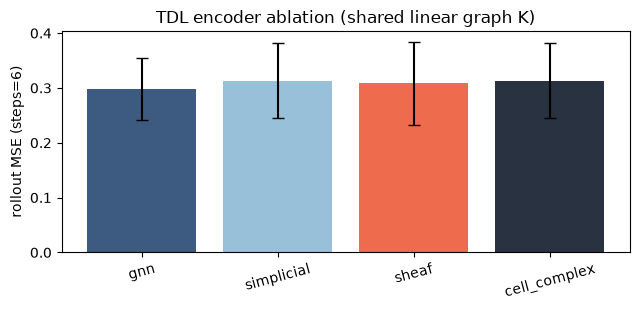

In [4]:
def mean_std(values: list[float]) -> tuple[float, float]:
    t = torch.tensor(values, dtype=torch.float64)
    if t.numel() == 1:
        return float(t.item()), 0.0
    return float(t.mean().item()), float(t.std(unbiased=True).item())


print(f"{'arm':13s}  {'mean_mse':>12s}  {'std_mse':>12s}  n={len(SEEDS)}")
summary = {}
for arm, values in results.items():
    mu, sigma = mean_std(values)
    summary[arm] = (mu, sigma)
    print(f"{arm:13s}  {mu:12.6f}  {sigma:12.6f}")

means = [summary[a][0] for a in ARM_BUILDERS]
stdevs = [summary[a][1] for a in ARM_BUILDERS]
spread = max(means) - min(means)
max_std = max(stdevs) if stdevs else 0.0
null_result = spread <= max_std + 1e-12
print(
    f"across-arm mean spread={spread:.6f}; max within-arm std={max_std:.6f}; "
    f"indistinguishable_within_noise={null_result}; "
    f"bit_identical_simplicial_cell_complex="
    f"{results['simplicial'] == results['cell_complex']}"
)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.bar(
    list(ARM_BUILDERS),
    means,
    yerr=stdevs if not IS_TEST else None,
    color=["#3d5a80", "#98c1d9", "#ee6c4d", "#293241"],
    capsize=4,
)
ax.set_ylabel(f"rollout MSE (steps={STEPS})")
ax.set_title("TDL encoder ablation (shared linear graph K)")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()


## Interpretation / discussion

The multi-seed bar chart answers the Motivation question narrowly: with a
shared linear graph $K$ on this diffusion complex, encode/decode choice
does not move holdout rollout MSE outside seed noise. That is consistent with
the fixture scale ($N \in \{3,4\}$, short trajectories) and with the
MVP design in which combinatorial $L_1$ and Hodge $L_0$ node mixing
coincide.

Practically, the notebook is a **trainability and honesty** check for the
factory peers, not a ranking of TDL architectures. The bit-identical
`simplicial` / `cell_complex` arms show that requiring `face_index` alone
does not buy cellular expressivity when the mixer ignores 2-cells. Diagonal
sheaf maps can stay close to the combinatorial baseline after a short budget;
larger gaps would need general restriction maps, richer complexes, or
complex-native latent operators — none of which this ablation measures.

Tradeoffs versus dedicated TDL libraries remain as stated in the package
limitations: keep these peers when the goal is a linear Koopman head with
inspectable encode stacks; prefer sheaf / CW frameworks when the domain
model is complex-native end-to-end.


## Takeaways

- Use this ablation to verify that `encoder="sheaf"` and
  `encoder="cell_complex"` train under a shared `koopman="graph"` head — not
  to pick a production TDL stack.
- Expect overlapping multi-seed intervals on the tiny diffusion complex; a
  null result is the teaching default.
- Expect bit-identical `simplicial` and `cell_complex` MSE with the current
  MVP: both mix with the same node Laplacian matvec; faces do not enter the
  mix.
- Do not read diagonal-sheaf near-ties as evidence against sheaf methods in
  general; change restriction maps, complex size, or the latent operator
  before claiming a TDL win or loss.
- Gotcha: `CellComplexGNNEncoder` raises without `face_index`, but that
  requirement is identity / API discipline, not higher-order mixing.


## Further reading

- Package API: `SheafGNNEncoder` / `SheafGNNDecoder`, `CellComplexGNNEncoder` /
  `CellComplexGNNDecoder`, `SimplicialEncoder` / `SimplicialDecoder`,
  `CellComplex`, `boundary_operator`, factory `encoder="sheaf"` /
  `"cell_complex"` / `"simplicial"` — see the
  [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
- Package docs:
  [Capabilities](https://koopmangraph.readthedocs.io/en/latest/capabilities.html)
  (sheaf / cell-complex MVP inventory) and
  [Scope and limitations](https://koopmangraph.readthedocs.io/en/latest/limitations.html)
  (when to prefer dedicated TDL frameworks); source RST also at
  [`docs/source/capabilities.rst`](../docs/source/capabilities.rst) and
  [`docs/source/limitations.rst`](../docs/source/limitations.rst)
- Related notebooks: `09_topology_ablation.ipynb` (encoder zoo on advection),
  `38_operator_factorization_ablation.ipynb` (shared-head ablation discipline);
  gallery:
  [tutorials](https://koopmangraph.readthedocs.io/en/latest/tutorials.html)
- Hansen, J., & Gebhart, T. (2020). Sheaf neural networks.
  *arXiv:2012.06333*. https://arxiv.org/abs/2012.06333
- Bodnar, C., Di Giovanni, F., Chamberlain, B., Liò, P., & Bronstein, M.
  (2022). Neural sheaf diffusion: A topological perspective on heterophily
  and oversmoothing in GNNs. *NeurIPS*.
  https://doi.org/10.52202/068431-1346
- Bodnar, C., Frasca, F., Otter, N., Wang, Y. G., Liò, P., Montúfar, G., &
  Bronstein, M. (2021). Weisfeiler and Lehman go cellular: CW networks.
  *NeurIPS*. https://arxiv.org/abs/2106.12575
